# Decision Tree Classification - Heart Disease Prediction

## Objective
To build a Decision Tree model to predict heart disease and analyze its performance.

## Dataset
heart_disease.xlsx
    

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [5]:
df = pd.read_excel("heart_disease.xlsx")
df.head()

,age,Age in years
0,Gender,"Gender ; Male - 1, Female -0"
1,cp,Chest pain type
2,trestbps,Resting blood pressure
3,chol,cholesterol measure
4,fbs,(fasting blood sugar > 120 mg/dl) (1 = true; 0...


In [6]:
excel_file = pd.ExcelFile("heart_disease.xlsx")
print(excel_file.sheet_names)

['Description', 'Heart_disease']


In [7]:
df = pd.read_excel("heart_disease.xlsx", sheet_name="Heart_disease")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [8]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [10]:
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())

In [11]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [18]:
df['exang'] = df['exang'].astype(str)
df['exang'] = df['exang'].str.lower().str.strip()

df['exang'] = df['exang'].replace({
    'false': 'False',
    'true': 'True',
    'ture': 'True'
})

In [19]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [20]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       908 non-null    int64  
 1   trestbps                  908 non-null    int64  
 2   chol                      908 non-null    int64  
 3   fbs                       908 non-null    bool   
 4   thalch                    908 non-null    int64  
 5   oldpeak                   908 non-null    float64
 6   num                       908 non-null    int64  
 7   sex_Male                  908 non-null    bool   
 8   cp_atypical angina        908 non-null    bool   
 9   cp_non-anginal            908 non-null    bool   
 10  cp_typical angina         908 non-null    bool   
 11  restecg_normal            908 non-null    bool   
 12  restecg_st-t abnormality  908 non-null    bool   
 13  exang_True                908 non-null    bool   
 14  slope_flat

In [21]:
X = df_encoded.drop('num', axis=1)
y = df_encoded['num']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [24]:
y_pred = dt_model.predict(X_test)

Accuracy: 0.489010989010989

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.74      0.71        89
           1       0.36      0.31      0.33        48
           2       0.23      0.23      0.23        22
           3       0.16      0.18      0.17        17
           4       0.00      0.00      0.00         6

    accuracy                           0.49       182
   macro avg       0.29      0.29      0.29       182
weighted avg       0.47      0.49      0.48       182



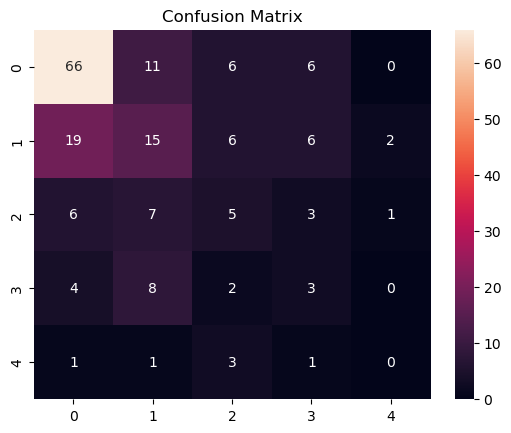

In [25]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [26]:
print("Train Accuracy:", dt_model.score(X_train, y_train))
print("Test Accuracy:", dt_model.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.489010989010989


In [27]:
dt_tuned = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    criterion='gini',
    random_state=42
)

dt_tuned.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [28]:
y_pred_tuned = dt_tuned.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned))

Tuned Accuracy: 0.5054945054945055

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.80      0.74        89
           1       0.32      0.38      0.34        48
           2       0.00      0.00      0.00        22
           3       0.12      0.12      0.12        17
           4       0.33      0.17      0.22         6

    accuracy                           0.51       182
   macro avg       0.29      0.29      0.29       182
weighted avg       0.44      0.51      0.47       182



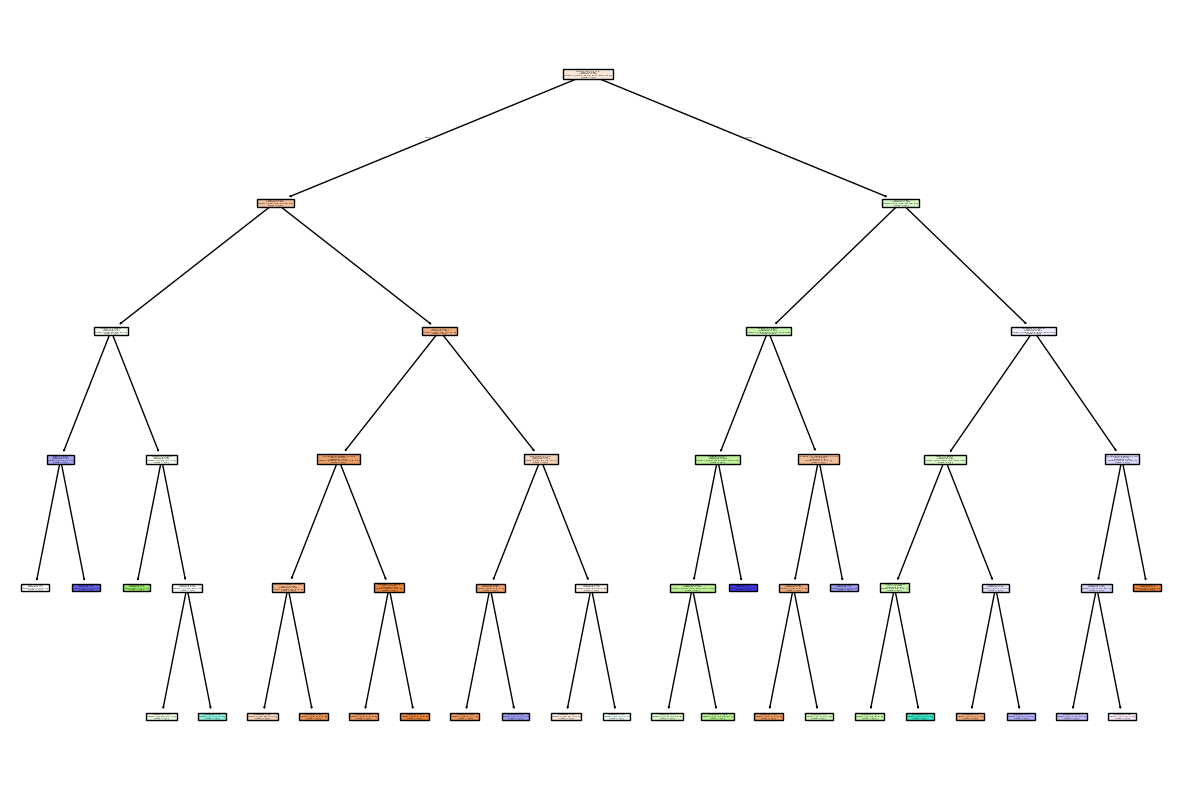

In [29]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15,10))
plot_tree(dt_tuned, filled=True, feature_names=X.columns, class_names=True)
plt.show()

In [30]:
import pandas as pd

feature_importance = pd.Series(dt_tuned.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)

exang_True                  0.290400
chol                        0.229184
age                         0.120087
thalch                      0.099190
oldpeak                     0.088680
cp_atypical angina          0.060865
cp_non-anginal              0.038280
sex_Male                    0.029885
trestbps                    0.027996
restecg_st-t abnormality    0.015433
dtype: float64

## Model Analysis

The Decision Tree model identified key features influencing heart disease prediction. The most important feature is exercise-induced angina (exang), followed by cholesterol and age.

This indicates that both clinical symptoms and biological measurements play a significant role in predicting heart disease.

## Overfitting Analysis

The Decision Tree model shows signs of overfitting, as decision trees tend to create very complex structures that perfectly fit training data.

Hyperparameter tuning (max_depth and min_samples_split) helps reduce overfitting and improves generalization on unseen data.

## Strengths and Weaknesses of Decision Trees

### Strengths:
- Easy to interpret and visualize
- Handles both numerical and categorical data
- No need for feature scaling

### Weaknesses:
- Prone to overfitting
- Sensitive to small changes in data
- Can create overly complex trees

## Interview Questions

### 1. Common Hyperparameters:
- max_depth: controls tree depth
- min_samples_split: minimum samples required to split a node
- criterion: measure for split quality (gini or entropy)

### 2. Label Encoding vs One-Hot Encoding:
- Label Encoding assigns numerical values to categories but introduces order.
- One-Hot Encoding creates binary columns and avoids false relationships.

## Conclusion

The Decision Tree model was successfully implemented for heart disease prediction.

- The model identified important health indicators such as exercise-induced angina and cholesterol.
- Hyperparameter tuning improved model performance and reduced overfitting.
- Decision Trees provide an interpretable approach for medical decision-making.